In [3]:
import os
import pandas as pd

# Directory containing the .flow files
directory = 'CTU_13/2_neris/'

# List to store individual dataframes
dataframes = []

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.flow'):
        # Read the file into a dataframe
        df = pd.read_csv(os.path.join(directory, filename))  # Adjust the reading method if necessary
        
        # Add a label column with the filename (without extension) as the label value
        #df['label'] = os.path.splitext(filename)[0]
        
        # Append the dataframe to the list
        dataframes.append(df)

# Concatenate all dataframes into a single dataframe
combined_4_df = pd.concat(dataframes, ignore_index=True)

combined_4_df.rename(columns={'Label': 'label'}, inplace=True)

# Remove rows where 'label' contains 'background'
#combined_4_df = combined_4_df[~combined_4_df['label'].str.contains('Background', case=False, na=False)]

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0
#combined_4_df['label'] = combined_4_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x else x))

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0, 'Background' -> 0
combined_4_df['label'] = combined_4_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x or 'Background' in x else x))

# Optionally reset the index if needed
combined_4_df.reset_index(drop=True, inplace=True)

# Display the combined dataframe
print(combined_4_df)


         TotBytes  SrcBytes  DstBytes  SrcGap  DstGap  sMeanPktSz  dMeanPktSz  \
0             508       208       300     0.0     0.0   69.333336        75.0   
1             184       122        62     0.0     0.0   61.000000        62.0   
2             184       122        62     0.0     0.0   61.000000        62.0   
3             184       122        62     0.0     0.0   61.000000        62.0   
4             184       122        62     0.0     0.0   61.000000        62.0   
...           ...       ...       ...     ...     ...         ...         ...   
1808117        62        62         0     0.0     0.0   62.000000         0.0   
1808118        79        79         0     NaN     NaN   79.000000         0.0   
1808119        77        77         0     NaN     NaN   77.000000         0.0   
1808120        66        66         0     0.0     0.0   66.000000         0.0   
1808121        78        78         0     NaN     NaN   78.000000         0.0   

         sMaxPktSz  dMaxPkt

In [8]:
import os
import yaml
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import re

def keep_features(df, features_to_keep):
    """
    Drop all columns from the DataFrame except for the specified features.
    
    Parameters:
    - df: pd.DataFrame, the input DataFrame
    - features_to_keep: list, list of column names to retain
    
    Returns:
    - pd.DataFrame with only the specified columns
    """
    # Ensure that the features_to_keep are in the DataFrame
    features_to_keep = [feature for feature in features_to_keep if feature in df.columns]
    
    # Return a DataFrame with only the specified features
    return df[features_to_keep]

# Function to preprocess each dataset
def preprocess_dataset(df):
    # Drop columns that contain only missing values
    df = df.dropna(axis=1, how='all')
    # Separate numeric and non-numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
    
    # Check if DataFrame has either numeric or non-numeric columns
    if not numeric_cols.empty or not non_numeric_cols.empty:
        # Handle missing values for numeric data
        if not numeric_cols.empty:
            imputer_numeric = SimpleImputer(strategy='mean')
            df_numeric = pd.DataFrame(imputer_numeric.fit_transform(df[numeric_cols]), columns=numeric_cols)
        else:
            df_numeric = pd.DataFrame()  # Empty DataFrame for numeric data if no numeric columns exist
        
        # Handle missing values for non-numeric data
        if not non_numeric_cols.empty:
            imputer_non_numeric = SimpleImputer(strategy='most_frequent')
            df_non_numeric = pd.DataFrame(imputer_non_numeric.fit_transform(df[non_numeric_cols]), columns=non_numeric_cols)
            # Convert non-numeric features to one-hot encoding
            encoder = OneHotEncoder(drop='first')
            encoded = encoder.fit_transform(df_non_numeric)
            encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(non_numeric_cols))
        else:
            encoded_df = pd.DataFrame()  # Empty DataFrame for encoded non-numeric data if no non-numeric columns exist
        
        # Concatenate processed numeric and encoded non-numeric data
        df_preprocessed = pd.concat([df_numeric, encoded_df], axis=1)

        '''
        features = [
            'pRetran', 'Max', 'sMeanPktSz', 'SrcRetra', 'PCRatio',
            'SrcWin,SrcLoss', 'DstRate', 'SrcLoad', 'TcpOpt_MwsS  T', 'Load', 'DstLoad', 'TcpRtt', 'Flgs_ e g      ',
            'Flgs_ e d      ', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'State_S_',
            'Cause_Status', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'IdleTime', 'Dur', 'SrcPkts', 'Flgs_ e s      ',
            'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'DstWin', 'TotPkts', 'DstPkts', 'Flgs_ e *      ', 'Mean',
            'SrcBytes', 'State__SA', 'TotBytes', 'Cause_Start', 'dMeanPktSz', 'DstRetra', 'SynAck'
        ]
        
        '''
        features = [
            'sTtl', 'AckDat', 'TcpRtt', 'SynAck', 'IdleTime', 'SrcBytes', 
            'DstWin', 'SrcWin', 'TcpOpt_MwsS  T', 'Min', 'Dur', 'pLoss',
            'Flgs_ e s      ', 'State_S_', 'TotPkts', 'DstPkts'
        ]
        
        # Drop all columns except the ones in features_to_keep
        df_preprocessed = keep_features(df_preprocessed, features)  

        # Scale features
        scaler = MinMaxScaler()
        df_scaled = pd.DataFrame(scaler.fit_transform(df_preprocessed), columns=df_preprocessed.columns)

        return df_scaled
    else:
        return pd.DataFrame()
    
# Step 1: Separate the label column
X_train = combined_4_df.drop(columns=['label'])
y_train = combined_4_df['label']

pre_df = preprocess_dataset(X_train)

pre_df['label'] = y_train

print(len(pre_df.columns))
pre_df['label']




17


0          0
1          0
2          0
3          0
4          0
          ..
1808117    0
1808118    0
1808119    0
1808120    0
1808121    0
Name: label, Length: 1808122, dtype: int64

=== CROSS-VALIDATION PROCESS ===
Fold 1: Val Accuracy = 0.9993, Test Accuracy = 0.9993
Fold 2: Val Accuracy = 0.9993, Test Accuracy = 0.9993
Fold 3: Val Accuracy = 0.9993, Test Accuracy = 0.9993
Fold 4: Val Accuracy = 0.9993, Test Accuracy = 0.9993
Fold 5: Val Accuracy = 0.9993, Test Accuracy = 0.9993

=== CROSS-VALIDATION RESULTS (VALIDATION SET) ===
Validation Accuracy: 0.9993 ± 0.0000
Validation F1 Score: 0.9843 ± 0.0005
Validation Recall: 0.9720 ± 0.0016
Validation Precision: 0.9972 ± 0.0012

=== TEST SET RESULTS (DURING CROSS-VALIDATION) ===
Test Accuracy: 0.9993 ± 0.0000
Test F1 Score: 0.9843 ± 0.0004
Test Recall: 0.9715 ± 0.0012
Test Precision: 0.9979 ± 0.0005

=== FINAL MODEL TRAINED ON FULL TRAIN+VALIDATION SET ===
Final Test Accuracy: 0.9993
Final Test F1 Score: 0.9849
Final Test Recall: 0.9728
Final Test Precision: 0.9978

=== FEATURE IMPORTANCE (Top 10) ===
            feature  importance
0              sTtl    0.257530
7            SrcWin    0.193807
13         State_S_   

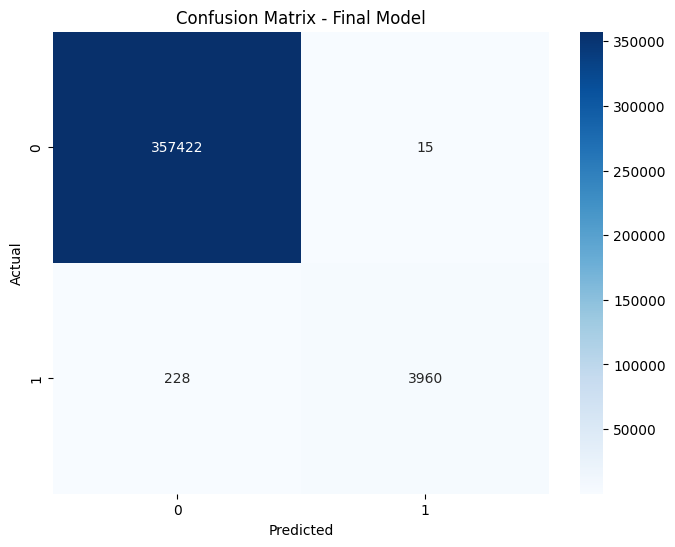

In [11]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
import numpy as np

# Assuming `pre_df` is your complete dataset

# Step 1: Separate features (X) and target (y)
X = pre_df.drop(columns=['label'])  # Features
y = pre_df['label']  # Target variable

# Step 2: Split data into train+validation (80%) and test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 3: Initialize the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=42)

# Step 4: Perform cross-validation on train+validation set
n_splits = 5  # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists for cross-validation scores (validation folds)
cv_accuracy_scores = []
cv_f1_scores = []
cv_recall_scores = []
cv_precision_scores = []

# Lists for test scores during cross-validation
test_accuracy_scores = []
test_f1_scores = []
test_recall_scores = []
test_precision_scores = []

print("=== CROSS-VALIDATION PROCESS ===")
for fold, (train_index, val_index) in enumerate(skf.split(X_train_val, y_train_val)):
    X_train_fold, X_val_fold = X_train_val.iloc[train_index], X_train_val.iloc[val_index]
    y_train_fold, y_val_fold = y_train_val.iloc[train_index], y_train_val.iloc[val_index]

    # Train the model on training fold
    clf.fit(X_train_fold, y_train_fold)

    # Validate on the validation fold
    y_val_pred = clf.predict(X_val_fold)
    
    # Test on the separate test set
    y_test_pred = clf.predict(X_test)

    # Evaluate metrics for the validation fold
    val_accuracy = accuracy_score(y_val_fold, y_val_pred)
    val_f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    val_recall = recall_score(y_val_fold, y_val_pred, average='macro')
    val_precision = precision_score(y_val_fold, y_val_pred, average='macro')
    
    cv_accuracy_scores.append(val_accuracy)
    cv_f1_scores.append(val_f1)
    cv_recall_scores.append(val_recall)
    cv_precision_scores.append(val_precision)

    # Evaluate metrics for the test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    test_recall = recall_score(y_test, y_test_pred, average='macro')
    test_precision = precision_score(y_test, y_test_pred, average='macro')
    
    test_accuracy_scores.append(test_accuracy)
    test_f1_scores.append(test_f1)
    test_recall_scores.append(test_recall)
    test_precision_scores.append(test_precision)
    
    print(f"Fold {fold+1}: Val Accuracy = {val_accuracy:.4f}, Test Accuracy = {test_accuracy:.4f}")

# Step 5: Print cross-validation results
print("\n" + "="*50)
print("=== CROSS-VALIDATION RESULTS (VALIDATION SET) ===")
print(f"Validation Accuracy: {np.mean(cv_accuracy_scores):.4f} ± {np.std(cv_accuracy_scores):.4f}")
print(f"Validation F1 Score: {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"Validation Recall: {np.mean(cv_recall_scores):.4f} ± {np.std(cv_recall_scores):.4f}")
print(f"Validation Precision: {np.mean(cv_precision_scores):.4f} ± {np.std(cv_precision_scores):.4f}")

print("\n=== TEST SET RESULTS (DURING CROSS-VALIDATION) ===")
print(f"Test Accuracy: {np.mean(test_accuracy_scores):.4f} ± {np.std(test_accuracy_scores):.4f}")
print(f"Test F1 Score: {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Test Recall: {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Test Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")

# Step 6: Final training on entire train+validation set and evaluation on test set
print("\n" + "="*50)
print("=== FINAL MODEL TRAINED ON FULL TRAIN+VALIDATION SET ===")
final_clf = RandomForestClassifier(n_estimators=10, random_state=42)
final_clf.fit(X_train_val, y_train_val)

# Predict on test set
y_test_pred_final = final_clf.predict(X_test)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_test_pred_final)
final_f1 = f1_score(y_test, y_test_pred_final, average='macro')
final_recall = recall_score(y_test, y_test_pred_final, average='macro')
final_precision = precision_score(y_test, y_test_pred_final, average='macro')

print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test F1 Score: {final_f1:.4f}")
print(f"Final Test Recall: {final_recall:.4f}")
print(f"Final Test Precision: {final_precision:.4f}")

# Feature importance
print("\n=== FEATURE IMPORTANCE (Top 10) ===")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': final_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

# Additional detailed evaluation
print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred_final))

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_test_pred_final)
print(cm)

# Plot confusion matrix (optional)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate


# Read the DataFrame (Replace this with your DataFrame reading code)
df = pre_df

# Split data into train and test sets first
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# List of features to compute incremental statistics
feature_list = ['SynAck', 'TcpRtt', 'AckDat']  # Replace with your actual features

def compute_incremental_stats(df, features):
    incremental_stats = pd.DataFrame(index=df.index)
    for feature in features:
        incremental_stats[f'{feature}_mean'] = df[feature].expanding().mean()
        incremental_stats[f'{feature}_median'] = df[feature].expanding().median()
        incremental_stats[f'{feature}_std'] = df[feature].expanding().std()
        incremental_stats[f'{feature}_max'] = df[feature].expanding().max()
    return incremental_stats

# Compute incremental statistics for training data
incremental_stats_train = compute_incremental_stats(train_df, feature_list)
incremental_stats_train.fillna(0, inplace=True)

# Add incremental statistics to training data
train_df_with_stats = pd.concat([train_df, incremental_stats_train], axis=1)

# Standardize the incremental features using training data
incremental_feature_cols = [col for col in train_df_with_stats.columns if col.endswith(('mean', 'median', 'std', 'max'))]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train_df_with_stats[incremental_feature_cols])

# Perform MiniBatch KMeans clustering on the training data
n_clusters = 3
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
train_clusters = kmeans.fit_predict(X_train_scaled)

# Add cluster labels to training DataFrame
train_df_with_stats['cluster'] = train_clusters

# Remove incremental features from final training DataFrame
train_df_final = train_df_with_stats.drop(columns=incremental_feature_cols)

# PROCESS TEST DATA
# Compute incremental statistics for test data
incremental_stats_test = compute_incremental_stats(test_df, feature_list)
incremental_stats_test.fillna(0, inplace=True)

# Add incremental statistics to test data
test_df_with_stats = pd.concat([test_df, incremental_stats_test], axis=1)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(test_df_with_stats[incremental_feature_cols])

# Assign clusters to test data using the trained KMeans model
test_clusters = kmeans.predict(X_test_scaled)

# Add cluster labels to test DataFrame
test_df_with_stats['cluster'] = test_clusters

# Remove incremental features from final test DataFrame
test_df_final = test_df_with_stats.drop(columns=incremental_feature_cols)

# Initialize dictionary to store classifiers and results
classifiers = {}
train_results = {}
test_results = {}

# Train and evaluate Random Forest Classifier for each cluster with cross-validation
for i in range(n_clusters):
    # Select training data for the current cluster
    train_cluster_data = train_df_final[train_df_final['cluster'] == i]
    
    # Select test data for the current cluster
    test_cluster_data = test_df_final[test_df_final['cluster'] == i]
    
    if len(train_cluster_data) == 0:
        print(f"Cluster {i} has no training data. Skipping.")
        continue
    
    if len(test_cluster_data) == 0:
        print(f"Cluster {i} has no test data. Skipping test evaluation.")
    
    # Separate features and target for training
    X_train_cluster = train_cluster_data.drop(columns=['label', 'cluster'])
    y_train_cluster = train_cluster_data['label']
    
    # Separate features and target for testing
    X_test_cluster = test_cluster_data.drop(columns=['label', 'cluster'])
    y_test_cluster = test_cluster_data['label']
    
    # Check if there is enough training data to perform cross-validation
    if len(X_train_cluster) < 5:
        print(f"Not enough data for cross-validation in cluster {i}.")
        continue
    
    # Initialize Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=30, random_state=42)
    
    # Perform cross-validation on training data
    cv_results = cross_validate(clf, X_train_cluster, y_train_cluster, cv=5, 
                               scoring=['accuracy', 'f1_macro', 'recall_macro', 'precision_macro'], 
                               return_train_score=False)
    
    # Fit the model on the entire training cluster data
    clf.fit(X_train_cluster, y_train_cluster)
    
    # Predict on training data
    y_train_pred = clf.predict(X_train_cluster)
    
    # Predict on test data (if available)
    if len(test_cluster_data) > 0:
        y_test_pred = clf.predict(X_test_cluster)
    
    # Compute confusion matrices
    train_cm = confusion_matrix(y_train_cluster, y_train_pred)
    
    # Store the classifier and training results
    classifiers[i] = clf
    train_results[i] = {
        'cv_accuracy': np.mean(cv_results['test_accuracy']),
        'cv_f1_score': np.mean(cv_results['test_f1_macro']),
        'cv_recall': np.mean(cv_results['test_recall_macro']),
        'cv_precision': np.mean(cv_results['test_precision_macro']),
        'confusion_matrix': train_cm,
        'classification_report': classification_report(y_train_cluster, y_train_pred)
    }
    
    # Store test results (if test data exists for this cluster)
    if len(test_cluster_data) > 0:
        test_accuracy = accuracy_score(y_test_cluster, y_test_pred)
        test_f1 = f1_score(y_test_cluster, y_test_pred, average='macro')
        test_recall = recall_score(y_test_cluster, y_test_pred, average='macro')
        test_precision = precision_score(y_test_cluster, y_test_pred, average='macro')
        test_cm = confusion_matrix(y_test_cluster, y_test_pred)
        
        test_results[i] = {
            'accuracy': test_accuracy,
            'f1_score': test_f1,
            'recall': test_recall,
            'precision': test_precision,
            'confusion_matrix': test_cm,
            'classification_report': classification_report(y_test_cluster, y_test_pred),
            'n_samples': len(test_cluster_data)
        }

# Print the training results for each cluster
print("="*60)
print("TRAINING RESULTS")
print("="*60)
for i, result in train_results.items():
    print(f"\nCluster {i} - Random Forest Classifier Performance (Training):")
    print(f"Cross-Validation Accuracy: {result['cv_accuracy']:.4f}")
    print(f"Cross-Validation F1 Score: {result['cv_f1_score']:.4f}")
    print(f"Cross-Validation Recall: {result['cv_recall']:.4f}")
    print(f"Cross-Validation Precision: {result['cv_precision']:.4f}")
    print("\nTraining Confusion Matrix:")
    print(result['confusion_matrix'])

# Print the test results for each cluster
print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
for i, result in test_results.items():
    print(f"\nCluster {i} - Random Forest Classifier Performance (Test):")
    print(f"Number of test samples: {result['n_samples']}")
    print(f"Test Accuracy: {result['accuracy']:.4f}")
    print(f"Test F1 Score: {result['f1_score']:.4f}")
    print(f"Test Recall: {result['recall']:.4f}")
    print(f"Test Precision: {result['precision']:.4f}")
    print("\nTest Confusion Matrix:")
    print(result['confusion_matrix'])
    print("\nTest Classification Report:")
    print(result['classification_report'])

# Calculate overall test performance (weighted average across clusters)
print("\n" + "="*60)
print("OVERALL TEST PERFORMANCE")
print("="*60)

if test_results:
    total_test_samples = sum(result['n_samples'] for result in test_results.values())
    overall_accuracy = sum(result['accuracy'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    overall_f1 = sum(result['f1_score'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    overall_recall = sum(result['recall'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    overall_precision = sum(result['precision'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    
    print(f"Overall Test Accuracy (weighted): {overall_accuracy:.4f}")
    print(f"Overall Test F1 Score (weighted): {overall_f1:.4f}")
    print(f"Overall Test Recall (weighted): {overall_recall:.4f}")
    print(f"Overall Test Precision (weighted): {overall_precision:.4f}")
    print(f"Total test samples across all clusters: {total_test_samples}")

# Print cluster distribution
print("\n" + "="*60)
print("CLUSTER DISTRIBUTION")
print("="*60)
print("Training data cluster distribution:")
print(train_df_final['cluster'].value_counts().sort_index())
print("\nTest data cluster distribution:")
print(test_df_final['cluster'].value_counts().sort_index())

Cluster 0 has no test data. Skipping test evaluation.
Cluster 2 has no test data. Skipping test evaluation.
TRAINING RESULTS

Cluster 0 - Random Forest Classifier Performance (Training):
Cross-Validation Accuracy: 0.9993
Cross-Validation F1 Score: 0.9845
Cross-Validation Recall: 0.9721
Cross-Validation Precision: 0.9976

Training Confusion Matrix:
[[1104762      21]
 [    526   12511]]

Cluster 1 - Random Forest Classifier Performance (Training):
Cross-Validation Accuracy: 0.9990
Cross-Validation F1 Score: 0.9776
Cross-Validation Recall: 0.9619
Cross-Validation Precision: 0.9946

Training Confusion Matrix:
[[121436      3]
 [    54   1338]]

Cluster 2 - Random Forest Classifier Performance (Training):
Cross-Validation Accuracy: 0.9992
Cross-Validation F1 Score: 0.9813
Cross-Validation Recall: 0.9662
Cross-Validation Precision: 0.9976

Training Confusion Matrix:
[[203520      2]
 [    82   2242]]

TEST RESULTS

Cluster 1 - Random Forest Classifier Performance (Test):
Number of test samp

## CDR-MLC with new feature and balance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

# Read the DataFrame
df = pre_df

# Split data into train and test sets first
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# ------------------------------------------------------------
# 1. Trend Score Calculation Functions
# ------------------------------------------------------------

def normalized_global_slope(window):
    """Calculate normalized global slope between -1 and 1"""
    if len(window) < 2:
        return 0
    x = np.arange(len(window))
    slope = np.polyfit(x, window, 1)[0]
    # Normalization based on window length
    max_possible_slope = (np.max(window) - np.min(window)) / len(window) if len(window) > 1 else 1
    if max_possible_slope == 0:
        return 0
    return slope / max_possible_slope

def pairwise_slopes(window):
    """Calculate slopes between all point pairs"""
    n = len(window)
    slopes = []
    for i in range(n):
        for j in range(i+1, n):
            if j > i:
                slope = (window[j] - window[i]) / (j - i) if (j - i) != 0 else 0
                slopes.append(slope)
    return np.array(slopes)

def consistency_factor(P):
    """Consistency factor based on slope variance"""
    if len(P) == 0:
        return 0
    # Using consistency metric (inverse of coefficient of variation)
    abs_slopes = np.abs(P)
    if np.mean(abs_slopes) == 0:
        return 0
    cv = np.std(abs_slopes) / np.mean(abs_slopes)  # coefficient of variation
    # Convert to consistency factor between 0 and 1
    return 1 / (1 + cv)

def contradiction_factor(G, P):
    """Contradiction factor between global and pairwise slopes"""
    if len(P) == 0:
        return 0
    # Count of pairwise slopes with opposite sign to G
    if G >= 0:
        contradictions = np.sum(P < 0)
    else:
        contradictions = np.sum(P > 0)
    return contradictions / len(P)

def calculate_trend_score(window):
    """Calculate final trend score"""
    G = normalized_global_slope(window)
    P = pairwise_slopes(window)
    CF = consistency_factor(P)
    CD = contradiction_factor(G, P)
    
    # Ensure values are within range
    G = np.clip(G, -1, 1)
    CF = np.clip(CF, 0, 1)
    CD = np.clip(CD, 0, 1)
    
    Trend_Score = G * CF * (1 - CD)
    return np.clip(Trend_Score, -1, 1)

def calculate_feature_trend_scores(df, feature_columns, window_size=10):
    """
    Calculate average trend score for each feature
    """
    trend_scores = {}
    
    for feature in feature_columns:
        scores = []
        data = df[feature].values
        
        # Calculate trend score for all windows
        for i in range(len(data) - window_size + 1):
            window = data[i:i+window_size]
            score = calculate_trend_score(window)
            scores.append(score)
        
        # Average of absolute scores
        if len(scores) > 0:
            trend_scores[feature] = np.mean(np.abs(scores))
        else:
            trend_scores[feature] = 0
    
    return trend_scores

# ------------------------------------------------------------
# 2. Edge-Priority Balanced Clustering Functions
# ------------------------------------------------------------

def balanced_cluster_assignment_with_edge_priority(X, y, kmeans_model, 
                                                   edge_threshold=0.15, 
                                                   alpha=0.3, beta=0.7,
                                                   top_k_clusters=3):
    """
    Cluster assignment with priority to edge samples for better label balance
    
    Parameters:
    -----------
    X : array-like, scaled data
    y : array-like, labels
    kmeans_model : trained KMeans model
    edge_threshold : threshold for edge detection (relative distance difference)
    alpha : weight for distance (0 to 1)
    beta : weight for balance (0 to 1)
    top_k_clusters : number of candidate clusters for edge samples
    """
    n_samples = X.shape[0]
    n_clusters = kmeans_model.n_clusters
    
    # Calculate distances to cluster centers
    distances = kmeans_model.transform(X)  # Distance from each sample to each cluster center
    
    # Initial assignment (closest cluster)
    initial_clusters = np.argmin(distances, axis=1)
    
    # Calculate current label distribution in clusters
    unique_labels = np.unique(y)
    label_distribution = np.zeros((n_clusters, len(unique_labels)))
    
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(initial_clusters == cluster_id)[0]
        if len(cluster_indices) > 0:
            cluster_labels = y[cluster_indices]
            for label_idx, label_val in enumerate(unique_labels):
                label_distribution[cluster_id, label_idx] = np.sum(cluster_labels == label_val)
    
    # Final assignment
    final_clusters = np.copy(initial_clusters)
    
    for i in range(n_samples):
        sample_distances = distances[i]
        sample_label = y[i]
        label_idx = np.where(unique_labels == sample_label)[0][0]
        
        # Sort clusters by distance
        sorted_indices = np.argsort(sample_distances)
        
        # Check if sample is on edge
        if len(sorted_indices) >= 2:
            closest_dist = sample_distances[sorted_indices[0]]
            second_dist = sample_distances[sorted_indices[1]]
            
            # Calculate relative difference
            if closest_dist > 0:
                diff_ratio = (second_dist - closest_dist) / closest_dist
            else:
                diff_ratio = 1.0  # If distance is zero
            
            # If sample is on edge (difference below threshold)
            if diff_ratio < edge_threshold:
                # Calculate scores for top K nearest clusters
                K = min(top_k_clusters, n_clusters)
                candidate_clusters = sorted_indices[:K]
                
                scores = []
                for cluster_id in candidate_clusters:
                    # Normalized distance (closer = higher score)
                    norm_distance = 1 - (sample_distances[cluster_id] / np.max(sample_distances[candidate_clusters]))
                    
                    # Cluster need score (clusters with fewer samples of this label get higher score)
                    max_label_count = np.max(label_distribution[:, label_idx])
                    if max_label_count > 0:
                        label_needs = 1 - (label_distribution[cluster_id, label_idx] / max_label_count)
                    else:
                        label_needs = 1
                    
                    # Combined score
                    score = alpha * norm_distance + beta * label_needs
                    scores.append(score)
                
                # Select cluster with highest score
                best_idx = np.argmax(scores)
                final_clusters[i] = candidate_clusters[best_idx]
                
                # Update distribution (approximate)
                label_distribution[final_clusters[i], label_idx] += 1
    
    return final_clusters

def analyze_cluster_balance(df_with_clusters, cluster_col='cluster', label_col='label'):
    """
    Analyze label distribution in clusters
    """
    n_clusters = df_with_clusters[cluster_col].nunique()
    unique_labels = sorted(df_with_clusters[label_col].unique())
    
    print("="*60)
    print("CLUSTER BALANCE ANALYSIS")
    print("="*60)
    
    # Distribution matrix
    distribution_matrix = pd.DataFrame(
        index=[f'Cluster {i}' for i in range(n_clusters)],
        columns=[f'Label {l}' for l in unique_labels]
    )
    
    # Balance scores (0 to 1, 1 = perfectly balanced)
    balance_scores = []
    
    for cluster_id in range(n_clusters):
        cluster_data = df_with_clusters[df_with_clusters[cluster_col] == cluster_id]
        total_in_cluster = len(cluster_data)
        
        if total_in_cluster > 0:
            row_data = []
            for label in unique_labels:
                count = len(cluster_data[cluster_data[label_col] == label])
                percentage = (count / total_in_cluster) * 100
                distribution_matrix.iloc[cluster_id, label] = f"{count} ({percentage:.1f}%)"
                row_data.append(count)
            
            # Calculate balance score (Gini impurity metric)
            proportions = np.array(row_data) / total_in_cluster
            gini_impurity = 1 - np.sum(proportions**2)
            normalized_gini = gini_impurity / (1 - 1/len(unique_labels))
            balance_scores.append(normalized_gini)
            
            print(f"\nCluster {cluster_id}:")
            print(f"  Total samples: {total_in_cluster}")
            print(f"  Balance score: {normalized_gini:.3f} (1.0 = perfectly balanced)")
            for label, count, prop in zip(unique_labels, row_data, proportions):
                print(f"  Label {label}: {count} samples ({prop*100:.1f}%)")
    
    print("\n" + "="*60)
    print("DISTRIBUTION MATRIX")
    print("="*60)
    print(distribution_matrix)
    
    # Average balance
    if balance_scores:
        print(f"\nAverage balance score: {np.mean(balance_scores):.3f}")
    
    return distribution_matrix, np.mean(balance_scores)

# ------------------------------------------------------------
# 3. Select Top 3 Features Based on Trend Score
# ------------------------------------------------------------

# List all features (except label)
all_features = [col for col in df.columns if col != 'label']

# Calculate trend scores for all features on training data
print("Calculating trend scores for all features...")
trend_scores_train = calculate_feature_trend_scores(train_df, all_features, window_size=10)

# Select top 3 features
top_features = sorted(trend_scores_train.items(), key=lambda x: x[1], reverse=True)[:3]
top_feature_names = [feature for feature, score in top_features]

print("\n" + "="*60)
print("TOP 3 FEATURES BASED ON TREND SCORE")
print("="*60)
for feature, score in top_features:
    print(f"{feature}: {score:.4f}")

# Use selected features in the rest of the code
feature_list = top_feature_names

# ------------------------------------------------------------
# 4. Compute Incremental Statistics
# ------------------------------------------------------------

def compute_incremental_stats(df, features):
    incremental_stats = pd.DataFrame(index=df.index)
    for feature in features:
        incremental_stats[f'{feature}_mean'] = df[feature].expanding().mean()
        incremental_stats[f'{feature}_median'] = df[feature].expanding().median()
        incremental_stats[f'{feature}_std'] = df[feature].expanding().std()
        incremental_stats[f'{feature}_max'] = df[feature].expanding().max()
    return incremental_stats

# Compute incremental statistics for training data
print(f"\nUsing features: {feature_list}")
incremental_stats_train = compute_incremental_stats(train_df, feature_list)
incremental_stats_train.fillna(0, inplace=True)

# Add incremental statistics to training data
train_df_with_stats = pd.concat([train_df, incremental_stats_train], axis=1)

# Standardize the incremental features using training data
incremental_feature_cols = [col for col in train_df_with_stats.columns if col.endswith(('mean', 'median', 'std'))]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train_df_with_stats[incremental_feature_cols])

# ------------------------------------------------------------
# 5. Edge-Priority Balanced Clustering on Training Data
# ------------------------------------------------------------

n_clusters = 3

# First, train MiniBatchKMeans model
print("\n" + "="*60)
print("PERFORMING EDGE-PRIORITY BALANCED CLUSTERING")
print("="*60)

# Train KMeans model
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_train_scaled)

# Get standard clustering for comparison
standard_clusters = kmeans.predict(X_train_scaled)
train_df_with_stats_temp = train_df_with_stats.copy()
train_df_with_stats_temp['cluster_standard'] = standard_clusters

print("\nStandard Clustering Balance Analysis:")
analyze_cluster_balance(train_df_with_stats_temp, 'cluster_standard', 'label')

# Apply edge-priority balanced clustering
print("\n" + "="*60)
print("APPLYING EDGE-PRIORITY BALANCED ASSIGNMENT")
print("="*60)

# Define balancing parameters
BALANCING_PARAMS = {
    'edge_threshold': 0.15,   # Samples with distance difference < 15% are edge samples
    'alpha': 0.3,            # Weight for distance (30%)
    'beta': 0.7,             # Weight for balance (70%)
    'top_k_clusters': 3,     # Max candidate clusters for edge samples
}

train_clusters_balanced = balanced_cluster_assignment_with_edge_priority(
    X_train_scaled, 
    train_df['label'].values, 
    kmeans_model=kmeans,
    **BALANCING_PARAMS
)

# Add balanced cluster labels to training DataFrame
train_df_with_stats['cluster'] = train_clusters_balanced

print("\nBalanced Clustering Balance Analysis:")
balance_matrix, avg_balance = analyze_cluster_balance(train_df_with_stats, 'cluster', 'label')

# Remove incremental features from final training DataFrame
train_df_final = train_df_with_stats.drop(columns=incremental_feature_cols)

# ------------------------------------------------------------
# 6. Process Test Data with Same Features and Model
# ------------------------------------------------------------

# Compute incremental statistics for test data
incremental_stats_test = compute_incremental_stats(test_df, feature_list)
incremental_stats_test.fillna(0, inplace=True)

# Add incremental statistics to test data
test_df_with_stats = pd.concat([test_df, incremental_stats_test], axis=1)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(test_df_with_stats[incremental_feature_cols])

# Assign clusters to test data using the balanced method
test_clusters_balanced = balanced_cluster_assignment_with_edge_priority(
    X_test_scaled,
    test_df['label'].values,
    kmeans_model=kmeans,
    **BALANCING_PARAMS
)

# Add cluster labels to test DataFrame
test_df_with_stats['cluster'] = test_clusters_balanced

# Remove incremental features from final test DataFrame
test_df_final = test_df_with_stats.drop(columns=incremental_feature_cols)

# ------------------------------------------------------------
# 7. Train and Evaluate Models for Each Cluster
# ------------------------------------------------------------

# Initialize dictionaries to store classifiers and results
classifiers = {}
train_results = {}
test_results = {}

# Train and evaluate Random Forest Classifier for each cluster with cross-validation
for i in range(n_clusters):
    # Select training data for the current cluster
    train_cluster_data = train_df_final[train_df_final['cluster'] == i]
    
    # Select test data for the current cluster
    test_cluster_data = test_df_final[test_df_final['cluster'] == i]
    
    if len(train_cluster_data) == 0:
        print(f"\nCluster {i} has no training data. Skipping.")
        continue
    
    if len(test_cluster_data) == 0:
        print(f"\nCluster {i} has no test data. Skipping test evaluation.")
    
    # Separate features and target for training
    X_train_cluster = train_cluster_data.drop(columns=['label', 'cluster'])
    y_train_cluster = train_cluster_data['label']
    
    # Separate features and target for testing
    X_test_cluster = test_cluster_data.drop(columns=['label', 'cluster'])
    y_test_cluster = test_cluster_data['label']
    
    # Check if there is enough training data to perform cross-validation
    if len(X_train_cluster) < 5:
        print(f"\nNot enough data for cross-validation in cluster {i}.")
        continue
    
    # Initialize Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=30, random_state=42)
    
    # Perform cross-validation on training data
    cv_results = cross_validate(clf, X_train_cluster, y_train_cluster, cv=5, 
                               scoring=['accuracy', 'f1_macro', 'recall_macro', 'precision_macro'], 
                               return_train_score=False)
    
    # Fit the model on the entire training cluster data
    clf.fit(X_train_cluster, y_train_cluster)
    
    # Predict on training data
    y_train_pred = clf.predict(X_train_cluster)
    
    # Predict on test data (if available)
    if len(test_cluster_data) > 0:
        y_test_pred = clf.predict(X_test_cluster)
    
    # Compute confusion matrices
    train_cm = confusion_matrix(y_train_cluster, y_train_pred)
    
    # Store the classifier and training results
    classifiers[i] = clf
    train_results[i] = {
        'cv_accuracy': np.mean(cv_results['test_accuracy']),
        'cv_f1_score': np.mean(cv_results['test_f1_macro']),
        'cv_recall': np.mean(cv_results['test_recall_macro']),
        'cv_precision': np.mean(cv_results['test_precision_macro']),
        'confusion_matrix': train_cm,
        'classification_report': classification_report(y_train_cluster, y_train_pred)
    }
    
    # Store test results (if test data exists for this cluster)
    if len(test_cluster_data) > 0:
        test_accuracy = accuracy_score(y_test_cluster, y_test_pred)
        test_f1 = f1_score(y_test_cluster, y_test_pred, average='macro')
        test_recall = recall_score(y_test_cluster, y_test_pred, average='macro')
        test_precision = precision_score(y_test_cluster, y_test_pred, average='macro')
        test_cm = confusion_matrix(y_test_cluster, y_test_pred)
        
        test_results[i] = {
            'accuracy': test_accuracy,
            'f1_score': test_f1,
            'recall': test_recall,
            'precision': test_precision,
            'confusion_matrix': test_cm,
            'classification_report': classification_report(y_test_cluster, y_test_pred),
            'n_samples': len(test_cluster_data)
        }

# ------------------------------------------------------------
# 8. Display Results
# ------------------------------------------------------------

# Print the training results for each cluster
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)
for i, result in train_results.items():
    print(f"\nCluster {i} - Random Forest Classifier Performance (Training):")
    print(f"Cross-Validation Accuracy: {result['cv_accuracy']:.4f}")
    print(f"Cross-Validation F1 Score: {result['cv_f1_score']:.4f}")
    print(f"Cross-Validation Recall: {result['cv_recall']:.4f}")
    print(f"Cross-Validation Precision: {result['cv_precision']:.4f}")

# Print the test results for each cluster
print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
for i, result in test_results.items():
    print(f"\nCluster {i} - Random Forest Classifier Performance (Test):")
    print(f"Number of test samples: {result['n_samples']}")
    print(f"Test Accuracy: {result['accuracy']:.4f}")
    print(f"Test F1 Score: {result['f1_score']:.4f}")
    print(f"Test Recall: {result['recall']:.4f}")
    print(f"Test Precision: {result['precision']:.4f}")

# Calculate overall test performance (weighted average across clusters)
print("\n" + "="*60)
print("OVERALL TEST PERFORMANCE")
print("="*60)

if test_results:
    total_test_samples = sum(result['n_samples'] for result in test_results.values())
    overall_accuracy = sum(result['accuracy'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    overall_f1 = sum(result['f1_score'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    overall_recall = sum(result['recall'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    overall_precision = sum(result['precision'] * result['n_samples'] for result in test_results.values()) / total_test_samples
    
    print(f"Overall Test Accuracy (weighted): {overall_accuracy:.4f}")
    print(f"Overall Test F1 Score (weighted): {overall_f1:.4f}")
    print(f"Overall Test Recall (weighted): {overall_recall:.4f}")
    print(f"Overall Test Precision (weighted): {overall_precision:.4f}")
    print(f"Total test samples across all clusters: {total_test_samples}")

# Print cluster distribution
print("\n" + "="*60)
print("CLUSTER DISTRIBUTION")
print("="*60)
print("Training data cluster distribution:")
print(train_df_final['cluster'].value_counts().sort_index())
print("\nTest data cluster distribution:")
print(test_df_final['cluster'].value_counts().sort_index())

# Optional: Display feature importance for each cluster
print("\n" + "="*60)
print("FEATURE IMPORTANCE FOR EACH CLUSTER")
print("="*60)
for i, clf in classifiers.items():
    if i in train_results:
        print(f"\nCluster {i} Feature Importance:")
        feature_importance = pd.DataFrame({
            'feature': X_train_cluster.columns,
            'importance': clf.feature_importances_
        }).sort_values('importance', ascending=False)
        print(feature_importance.head(10))

# ------------------------------------------------------------
# 9. Summary of Balancing Results
# ------------------------------------------------------------
print("\n" + "="*60)
print("BALANCING METHOD SUMMARY")
print("="*60)
print(f"Balancing Parameters Used:")
print(f"  Edge threshold: {BALANCING_PARAMS['edge_threshold']}")
print(f"  Distance weight (alpha): {BALANCING_PARAMS['alpha']}")
print(f"  Balance weight (beta): {BALANCING_PARAMS['beta']}")
print(f"  Top K clusters: {BALANCING_PARAMS['top_k_clusters']}")
print(f"\nAverage cluster balance score: {avg_balance:.3f}")